In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [36]:
# from sklearn.datasets import fetch_openml
# import pandas as pd

# # Load dataset
# heart = fetch_openml(name='heart-disease', version=1, as_frame=True)

# # Features
# X = heart.data

# # Target
# y = heart.target

# # Convert to DataFrame
# df = pd.concat([X, y], axis=1)

# # Show first 5 rows
# print(df.head())

In [37]:
df = pd.read_csv('heart.csv')

In [38]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [39]:
df.sample()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
537,52,1,1,120,325,0,1,172,0,0.2,2,0,2,1


In [40]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [42]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [43]:
df.shape

(1025, 14)

In [44]:
df.duplicated().sum()

723

In [45]:
df["target"].value_counts() 

target
1    526
0    499
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='count'>

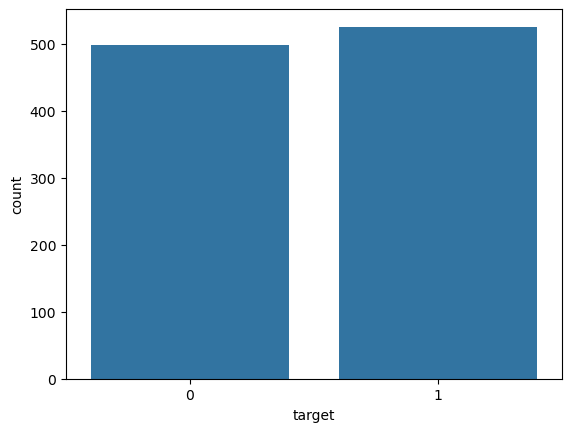

In [46]:
sns.countplot(x="target", data=df)

In [47]:
X = df.drop("target", axis=1)
y = df["target"]

In [48]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

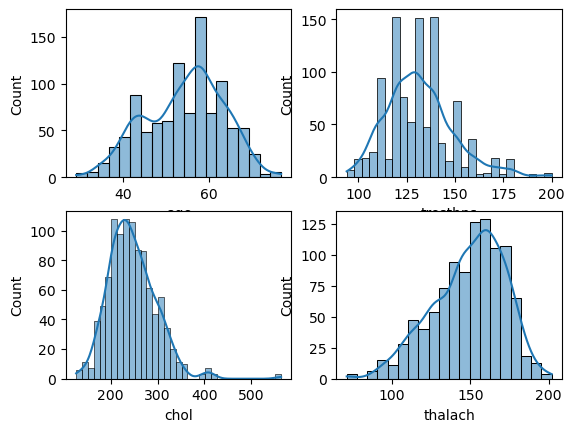

In [49]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var], kde=True)

plotting("age",1)
plotting("trestbps",2)
plotting("chol",3)
plotting("thalach",4)

In [50]:
df["chol"].value_counts()

chol
204    21
234    21
197    19
212    18
254    17
       ..
164     3
394     3
215     3
160     3
141     3
Name: count, Length: 152, dtype: int64

<Axes: xlabel='sex', ylabel='count'>

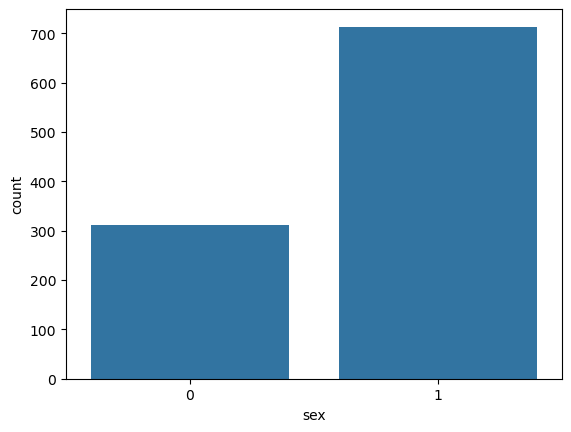

In [51]:
sns.countplot(x="sex", data=df)

<Axes: xlabel='chol', ylabel='count'>

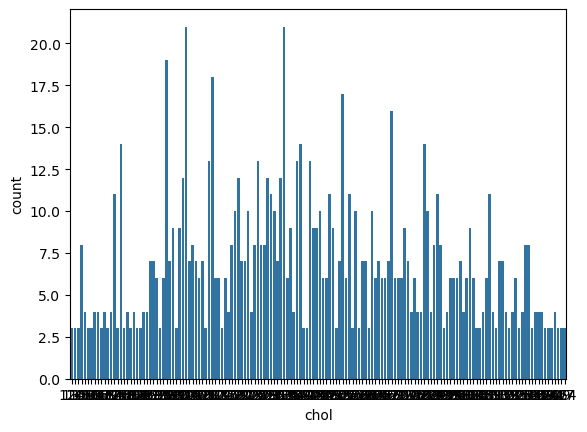

In [52]:
sns.countplot(x="chol", data=df)

<Axes: xlabel='chol', ylabel='Count'>

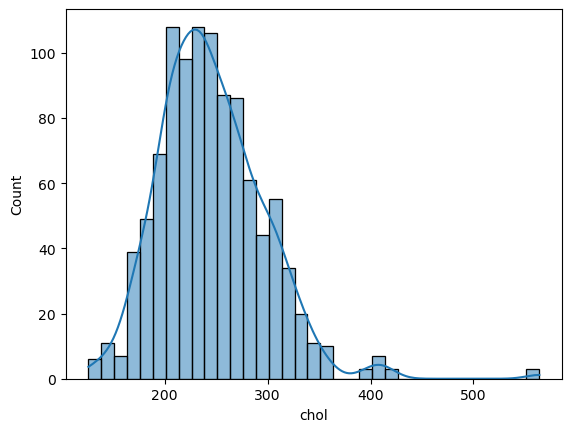

In [53]:
sns.histplot(df["chol"], kde=True)

<Axes: xlabel='sex', ylabel='count'>

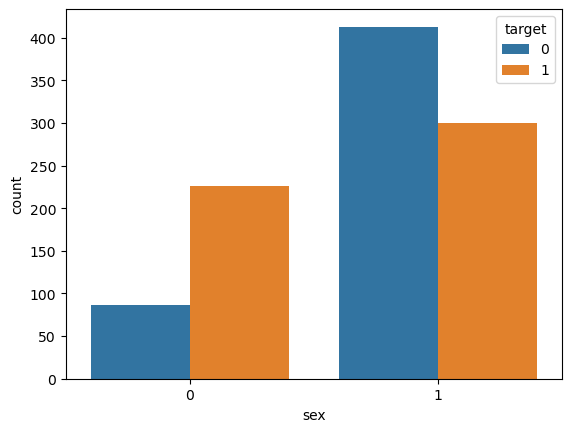

In [54]:
sns.countplot(x=df["sex"], hue=df["target"])

In [55]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

<Axes: xlabel='target', ylabel='age'>

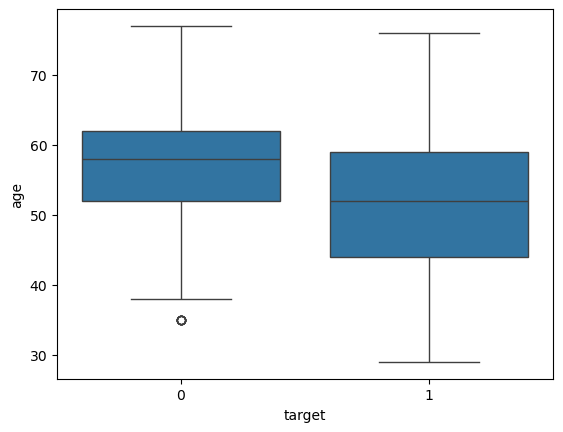

In [56]:
sns.boxplot(x="target", y="age", data=df)

<Axes: xlabel='target', ylabel='age'>

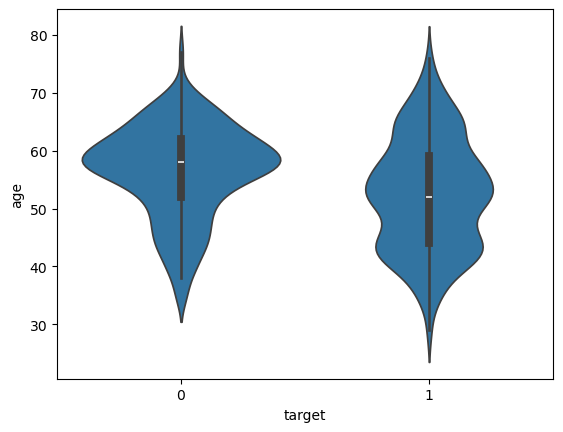

In [57]:
sns.violinplot(x="target", y="age", data=df)

<Axes: >

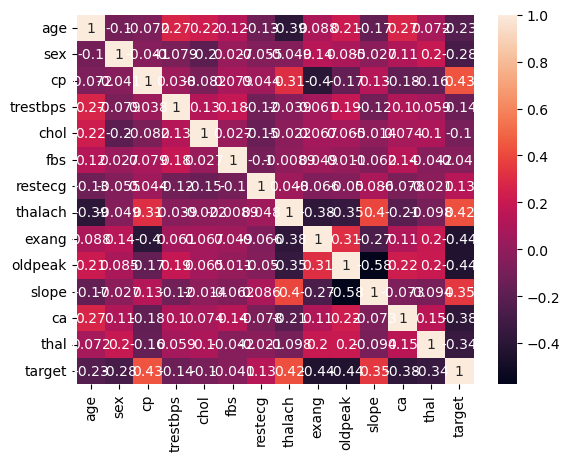

In [58]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [59]:
X = df.drop("target", axis=1)
y = df["target"]

In [60]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [61]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "Naive Bayes" : GaussianNB(),
    "Decision Tree" : DecisionTreeClassifier(),
    "SVM(RBF Kernel)" : SVC(probability=True),
    "KNN" : KNeighborsClassifier()
}

In [63]:
results = []

In [67]:
from sklearn.metrics import f1_score
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test,y_pred)
    F1 = f1_score(y_test,y_pred)
    results.append({
        "Model": name,
        "Accuracy": round(acc,4),
        "f1 Score": round(F1,4)
    })

In [65]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.7951, 'f1 Score': 0.8108},
 {'Model': 'Naive Bayes', 'Accuracy': 0.8, 'f1 Score': 0.8178},
 {'Model': 'Decision Tree', 'Accuracy': 0.9854, 'f1 Score': 0.9852},
 {'Model': 'SVM(RBF Kernel)', 'Accuracy': 0.8878, 'f1 Score': 0.894},
 {'Model': 'KNN', 'Accuracy': 0.8341, 'f1 Score': 0.844}]

In [66]:
import joblib

joblib.dump(models['KNN'],'KNN_heart.pkl')
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print("KNN model saved successfully")

KNN model saved successfully
